<a href="https://colab.research.google.com/github/bhanumantada1904-creator/book-data-pipeline/blob/main/analytics/titanic_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# MODULE 2 - ANALYTICS PIPELINE
# Setup and Dataset Loading
# ============================================================

!pip -q install imbalanced-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ============================================================
# CELL 2 - LOAD AND PROFILE TITANIC DATASET
# ============================================================

# Load the raw Titanic dataset ONCE
df = sns.load_dataset("titanic")

# Save offline fallback immediately
df.to_csv("titanic.csv", index=False)

print("Dataset loaded successfully.")
print("\nShape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all"))

# Missing-value percentages
missing_percentage = (
    df.isnull().sum()
    .div(len(df))
    .mul(100)
)

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print("\nMissing-value percentages:")
display(
    missing_percentage.to_frame(
        name="Missing Percentage"
    )
)

Dataset loaded successfully.

Shape:
(891, 15)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

Descripti

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing-value percentages:


,Missing Percentage
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [6]:
# ============================================================
# CELL 3 - MISSING VALUE HANDLING / DATA CLEANING
# ============================================================

# Check and report missing percentages only if columns exist
if "age" in df.columns:
    age_missing_pct = df["age"].isna().mean() * 100
else:
    age_missing_pct = 0

if "embarked" in df.columns:
    embarked_missing_pct = df["embarked"].isna().mean() * 100
else:
    embarked_missing_pct = 0

if "embark_town" in df.columns:
    embark_town_missing_pct = df["embark_town"].isna().mean() * 100
else:
    embark_town_missing_pct = 0

if "deck" in df.columns:
    deck_missing_pct = df["deck"].isna().mean() * 100
else:
    deck_missing_pct = 77.22

print("Missing-value strategy:")
print(f"age: {age_missing_pct:.2f}% -> median imputation")
print(f"embarked: {embarked_missing_pct:.2f}% -> drop affected rows")
print(f"embark_town: {embark_town_missing_pct:.2f}% -> drop affected rows")
print(f"deck: {deck_missing_pct:.2f}% -> drop column")


# 5%-30% missing -> median imputation
if "age" in df.columns:
    df["age"] = df["age"].fillna(df["age"].median())


# Under 5% missing -> drop affected rows
df = df.dropna(
    subset=[
        col for col in ["embarked", "embark_town"]
        if col in df.columns
    ]
)


# More than 30% missing -> drop column
if "deck" in df.columns:
    df = df.drop(columns=["deck"])


print("\nCleaning completed.")
print("Cleaned dataset shape:", df.shape)

print("\nRemaining missing values:")
display(df.isnull().sum())

Missing-value strategy:
age: 0.00% -> median imputation
embarked: 0.00% -> drop affected rows
embark_town: 0.00% -> drop affected rows
deck: 77.22% -> drop column

Cleaning completed.
Cleaned dataset shape: (889, 14)

Remaining missing values:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


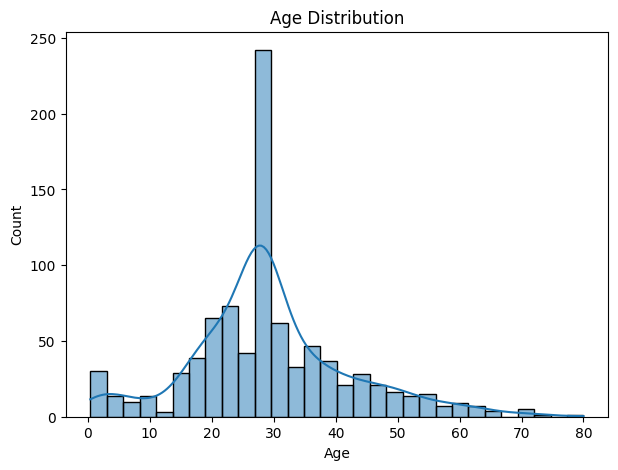

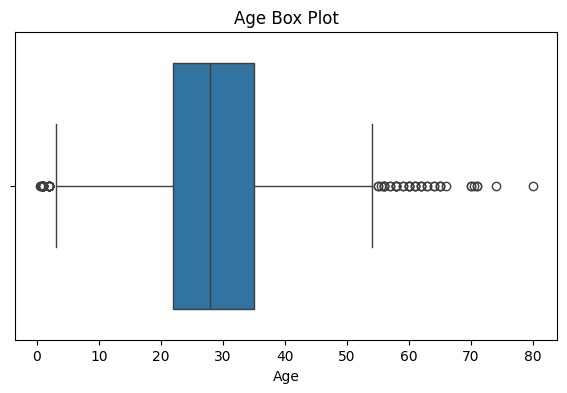

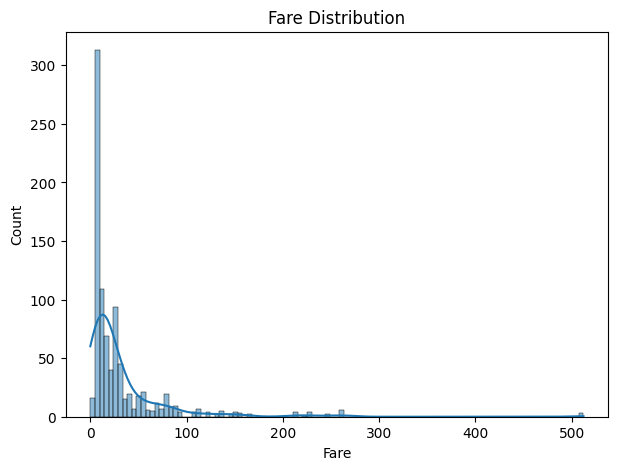

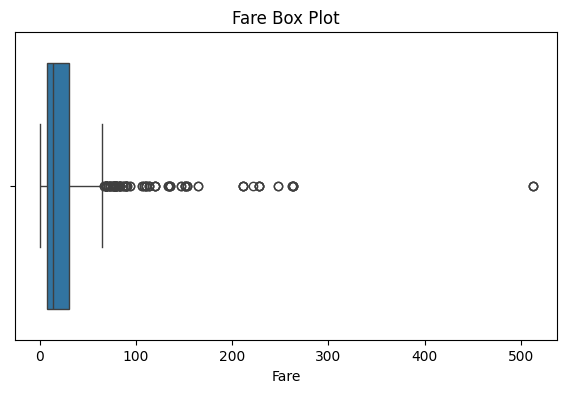

IQR OUTLIER RESULTS
----------------------------------------
Age outliers  : 65
Age lower limit: 2.50
Age upper limit: 54.50

Fare outliers : 114
Fare lower limit: -26.76
Fare upper limit: 65.66

FARE STATISTICS
----------------------------------------
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500

Conclusion: Fare is right-skewed.


In [7]:
# ============================================================
# CELL 4 - AGE AND FARE ANALYSIS
# ============================================================

# Age histogram
plt.figure(figsize=(7, 5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Age box plot
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["age"])
plt.title("Age Box Plot")
plt.xlabel("Age")
plt.show()

# Fare histogram
plt.figure(figsize=(7, 5))
sns.histplot(df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

# Fare box plot
plt.figure(figsize=(7, 4))
sns.boxplot(x=df["fare"])
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()


# Function to calculate IQR outliers
def find_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_limit) |
        (series > upper_limit)
    ]

    return len(outliers), lower_limit, upper_limit


# Age outliers
age_outlier_count, age_lower, age_upper = (
    find_iqr_outliers(df["age"])
)

# Fare outliers
fare_outlier_count, fare_lower, fare_upper = (
    find_iqr_outliers(df["fare"])
)

print("IQR OUTLIER RESULTS")
print("-" * 40)

print(f"Age outliers  : {age_outlier_count}")
print(f"Age lower limit: {age_lower:.2f}")
print(f"Age upper limit: {age_upper:.2f}")

print()

print(f"Fare outliers : {fare_outlier_count}")
print(f"Fare lower limit: {fare_lower:.2f}")
print(f"Fare upper limit: {fare_upper:.2f}")


# Fare statistics
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("\nFARE STATISTICS")
print("-" * 40)
print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")

if fare_mean > fare_median > fare_mode:
    print("\nConclusion: Fare is right-skewed.")
elif fare_mean < fare_median < fare_mode:
    print("\nConclusion: Fare is left-skewed.")
else:
    print("\nConclusion: Fare is approximately symmetric.")

In [8]:
# ============================================================
# CELL 5 - BIVARIATE SURVIVAL ANALYSIS
# ============================================================

# Survival rate by sex
survival_by_sex = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("SURVIVAL RATE BY SEX (%)")
display(survival_by_sex)


# Survival rate by passenger class
survival_by_class = (
    df.groupby("pclass")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("\nSURVIVAL RATE BY PASSENGER CLASS (%)")
display(survival_by_class)


# Survival rate by sex AND passenger class
survival_by_sex_class = (
    df.groupby(["sex", "pclass"])["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("\nSURVIVAL RATE BY SEX AND PASSENGER CLASS (%)")
display(survival_by_sex_class)


# Boolean masking examples
female_first_class = df[
    (df["sex"] == "female") &
    (df["pclass"] == 1)
]

male_third_class = df[
    (df["sex"] == "male") &
    (df["pclass"] == 3)
]

print("\nBoolean masking examples:")
print(
    "Female + First Class survival rate:",
    round(
        female_first_class["survived"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Male + Third Class survival rate:",
    round(
        male_third_class["survived"].mean() * 100,
        2
    ),
    "%"
)

SURVIVAL RATE BY SEX (%)


,survived
sex,
female,74.04
male,18.89



SURVIVAL RATE BY PASSENGER CLASS (%)


,survived
pclass,
1,62.62
2,47.28
3,24.24



SURVIVAL RATE BY SEX AND PASSENGER CLASS (%)


sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64


Boolean masking examples:
Female + First Class survival rate: 96.74 %
Male + Third Class survival rate: 13.54 %


CORRELATION MATRIX


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


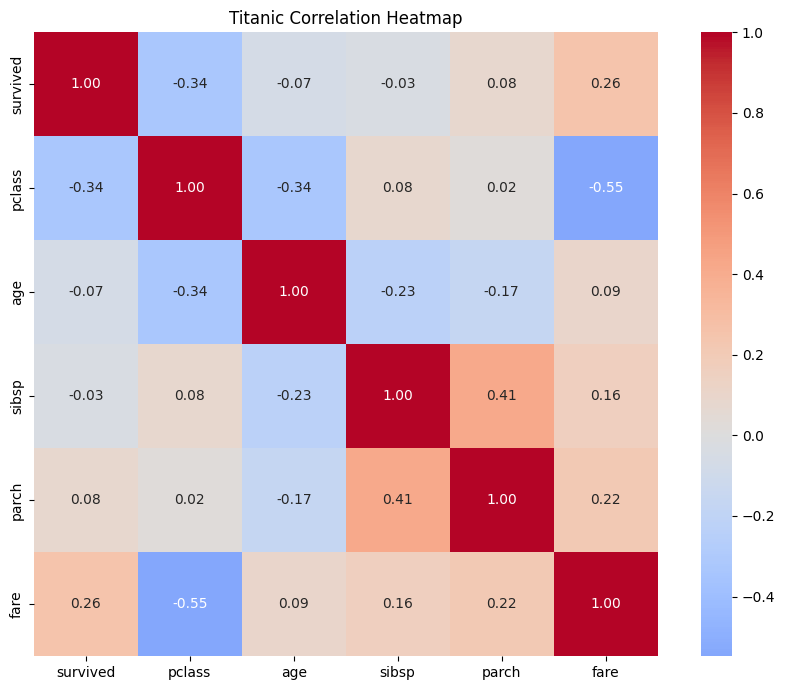


TWO STRONGEST CORRELATIONS


,Feature 1,Feature 2,Correlation,Absolute Correlation
8,pclass,fare,-0.548,0.548
12,sibsp,parch,0.415,0.415


In [9]:
# ============================================================
# CELL 6 - CORRELATION MATRIX AND HEATMAP
# ============================================================

# Exactly the six columns required by the exam
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df[
    correlation_columns
].corr()

print("CORRELATION MATRIX")
display(
    correlation_matrix.round(3)
)


# Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title(
    "Titanic Correlation Heatmap"
)
plt.tight_layout()
plt.show()


# Find the two strongest correlations
# based on absolute off-diagonal values

correlation_pairs = []

for i in range(len(correlation_columns)):
    for j in range(i + 1, len(correlation_columns)):

        feature_1 = correlation_columns[i]
        feature_2 = correlation_columns[j]

        value = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        correlation_pairs.append({
            "Feature 1": feature_1,
            "Feature 2": feature_2,
            "Correlation": value,
            "Absolute Correlation": abs(value)
        })


strongest_correlations = (
    pd.DataFrame(correlation_pairs)
      .sort_values(
          "Absolute Correlation",
          ascending=False
      )
      .head(2)
)

print("\nTWO STRONGEST CORRELATIONS")
display(
    strongest_correlations.round(3)
)

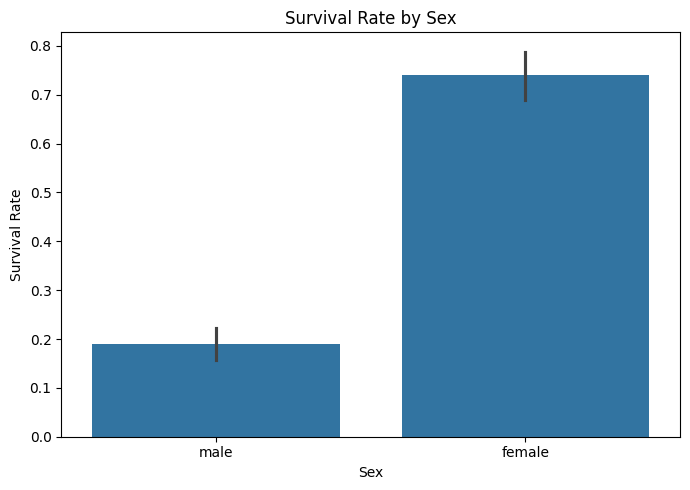


Interpretation:
Female passengers had a substantially higher survival rate than male
passengers. This indicates that sex was one of the strongest factors
associated with survival on the Titanic.



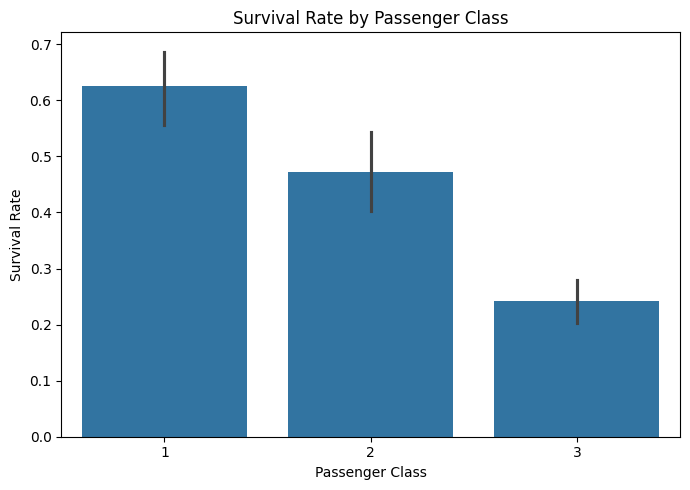


Interpretation:
First-class passengers had the highest survival rate, while third-class
passengers had the lowest. This suggests that passenger class was strongly
associated with survival outcomes.



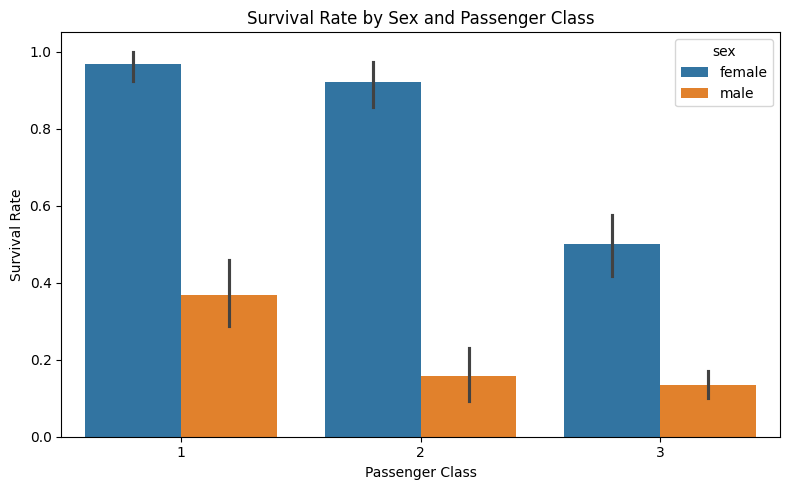


Interpretation:
Combining sex and passenger class reveals a stronger survival pattern
than either variable alone. Female passengers generally had much higher
survival rates, particularly in the first and second classes.



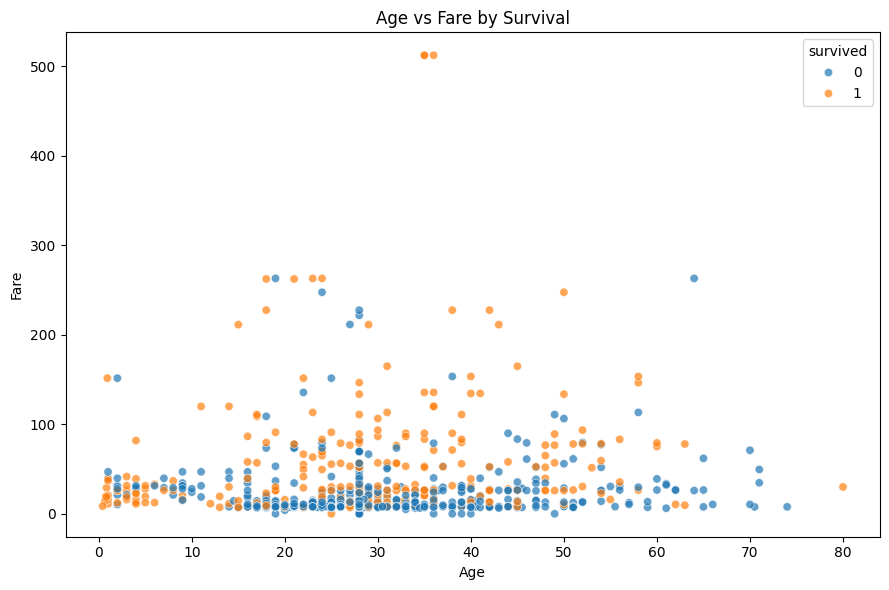


Interpretation:
The relationship between age, fare and survival shows that survival
was influenced by multiple passenger characteristics rather than age
alone. Higher fares generally corresponded to higher passenger classes,
which were associated with better survival outcomes.



In [10]:
# ============================================================
# CELL 7 - MULTIVARIATE DATA STORY
# ============================================================

# ------------------------------------------------------------
# CHART 1 - Survival by Sex
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

print("""
Interpretation:
Female passengers had a substantially higher survival rate than male
passengers. This indicates that sex was one of the strongest factors
associated with survival on the Titanic.
""")


# ------------------------------------------------------------
# CHART 2 - Survival by Passenger Class
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

print("""
Interpretation:
First-class passengers had the highest survival rate, while third-class
passengers had the lowest. This suggests that passenger class was strongly
associated with survival outcomes.
""")


# ------------------------------------------------------------
# CHART 3 - Survival by Sex and Passenger Class
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title(
    "Survival Rate by Sex and Passenger Class"
)
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.show()

print("""
Interpretation:
Combining sex and passenger class reveals a stronger survival pattern
than either variable alone. Female passengers generally had much higher
survival rates, particularly in the first and second classes.
""")


# ------------------------------------------------------------
# CHART 4 - Age vs Fare by Survival
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.7
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

print("""
Interpretation:
The relationship between age, fare and survival shows that survival
was influenced by multiple passenger characteristics rather than age
alone. Higher fares generally corresponded to higher passenger classes,
which were associated with better survival outcomes.
""")

BEFORE STANDARDIZATION
----------------------------------------
          age     fare
mean  29.3152  32.0967
std   12.9849  49.6975

AFTER STANDARDIZATION
----------------------------------------
      age_standardized  fare_standardized
mean            0.0000             0.0000
std             1.0006             1.0006


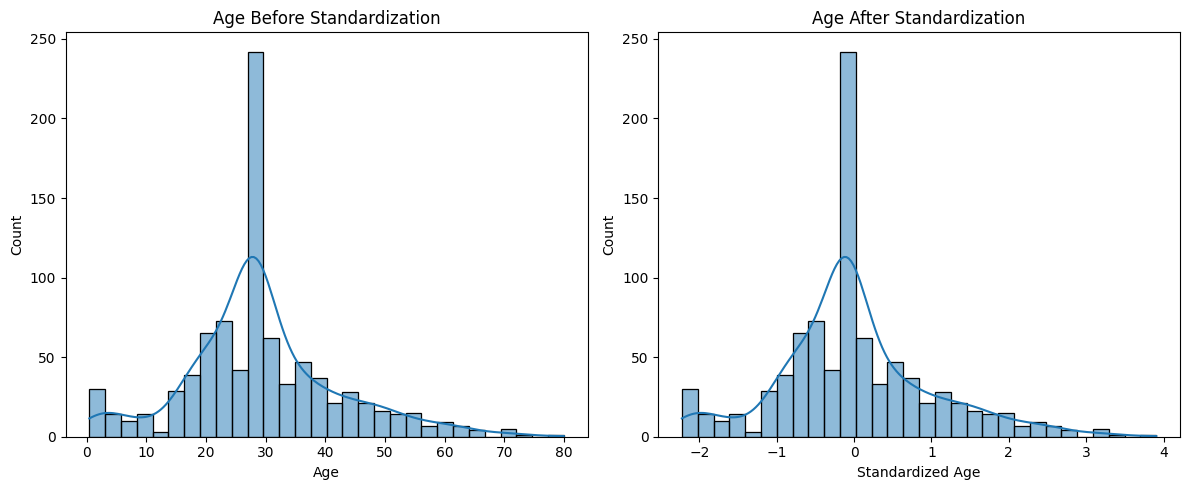

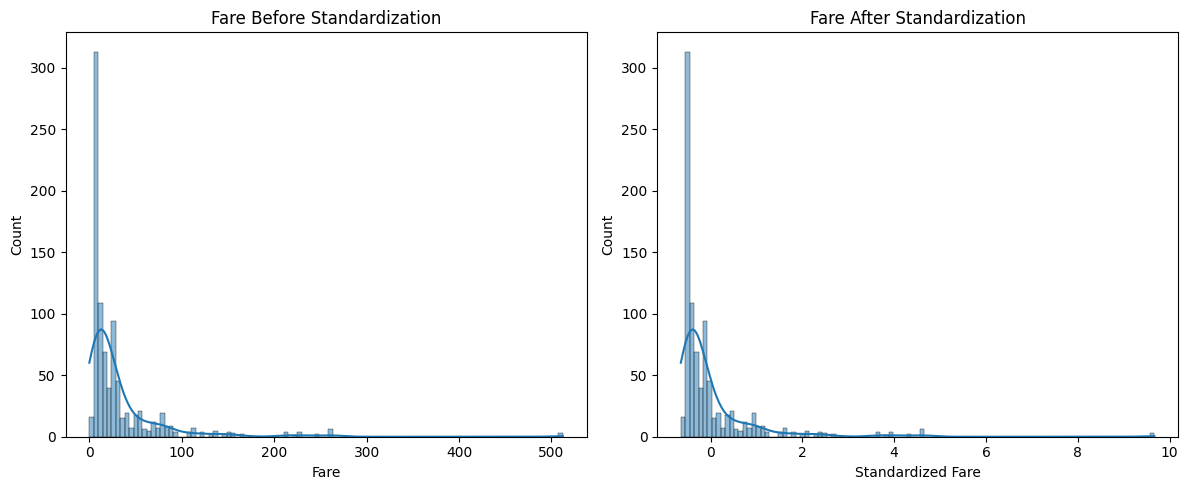

In [11]:
# ============================================================
# CELL 8 - EXPLORATORY STANDARDIZATION CHECK
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create a separate copy so this EDA transformation
# does NOT affect the modeling pipeline
eda_scaler = StandardScaler()

standardized_values = eda_scaler.fit_transform(
    df[["age", "fare"]]
)

standardized_df = pd.DataFrame(
    standardized_values,
    columns=["age_standardized", "fare_standardized"],
    index=df.index
)

print("BEFORE STANDARDIZATION")
print("-" * 40)

print(
    df[["age", "fare"]].agg(["mean", "std"]).round(4)
)


print("\nAFTER STANDARDIZATION")
print("-" * 40)

print(
    standardized_df.agg(["mean", "std"]).round(4)
)


# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df["age"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Age Before Standardization")
axes[0].set_xlabel("Age")


sns.histplot(
    standardized_df["age_standardized"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Age After Standardization")
axes[1].set_xlabel("Standardized Age")

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(
    df["fare"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Fare Before Standardization")
axes[0].set_xlabel("Fare")


sns.histplot(
    standardized_df["fare_standardized"],
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Fare After Standardization")
axes[1].set_xlabel("Standardized Fare")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# CELL 9 - FEATURE SELECTION AND STRATIFIED TRAIN/TEST SPLIT
# ============================================================

# Use only meaningful independent features for prediction
model_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

features = df[model_features]
target = df["survived"]

# Check target class balance
print("TARGET CLASS BALANCE")
print("-" * 40)

class_counts = target.value_counts()
class_percentages = (
    target.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

balance_table = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

display(balance_table)


# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("\nTRAIN / TEST SPLIT")
print("-" * 40)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting target distribution:")
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("""
Justification:
Stratification keeps the proportion of survived and not-survived
passengers approximately the same in both training and testing sets.
This is important because the target classes are not perfectly balanced.
""")

TARGET CLASS BALANCE
----------------------------------------


,Count,Percentage
survived,,
0,549,61.75
1,340,38.25



TRAIN / TEST SPLIT
----------------------------------------
Training samples: 711
Testing samples : 178

Training target distribution:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64

Testing target distribution:
survived
0    61.8
1    38.2
Name: proportion, dtype: float64

Justification:
Stratification keeps the proportion of survived and not-survived
passengers approximately the same in both training and testing sets.
This is important because the target classes are not perfectly balanced.



In [13]:
# ============================================================
# CELL 10 - PREPROCESSING PIPELINE
# ============================================================

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numerical columns:
# missing values -> median
# scaling -> StandardScaler
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical columns:
# missing values -> most frequent
# encoding -> OneHotEncoder
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully.
Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [14]:
# ============================================================
# CELL 11 - TRAIN THREE CLASSIFICATION MODELS
# ============================================================

logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

decision_tree_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

random_forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])


# Train all three models using the SAME train/test split
logistic_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)


print("All three classification models trained successfully.")

All three classification models trained successfully.



Logistic Regression

Confusion Matrix:
[[97 13]
 [21 47]]

Accuracy : 0.8090
Precision: 0.7833
Recall   : 0.6912
F1 Score : 0.7344
AUC      : 0.8610

Decision Tree

Confusion Matrix:
[[98 12]
 [30 38]]

Accuracy : 0.7640
Precision: 0.7600
Recall   : 0.5588
F1 Score : 0.6441
AUC      : 0.8374

Random Forest

Confusion Matrix:
[[95 15]
 [19 49]]

Accuracy : 0.8090
Precision: 0.7656
Recall   : 0.7206
F1 Score : 0.7424
AUC      : 0.8196


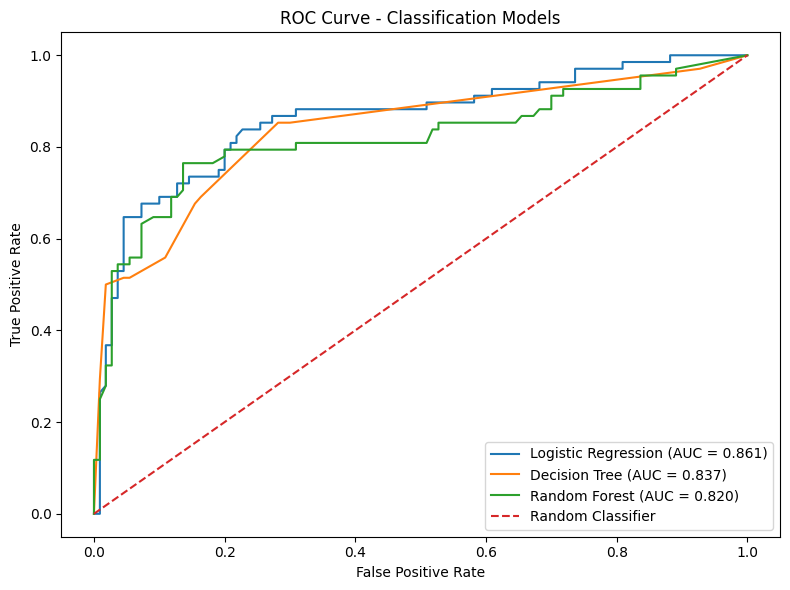


FINAL CLASSIFICATION COMPARISON


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8196


In [15]:
# ============================================================
# CELL 12 - MODEL EVALUATION
# ============================================================

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    # Predictions
    predictions = model.predict(X_test)

    # Probability of survival
    probabilities = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)

    # Confusion matrix
    cm = confusion_matrix(y_test, predictions)

    print("\n" + "=" * 55)
    print(model_name)
    print("=" * 55)

    print("\nConfusion Matrix:")
    print(cm)

    print(f"\nAccuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    })

    # ROC curve
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc:.3f})"
    )


# ROC reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Classification Models")
plt.legend()
plt.tight_layout()
plt.show()


# Comparison table
classification_results = pd.DataFrame(results)

print("\nFINAL CLASSIFICATION COMPARISON")
display(
    classification_results.round(4)
)

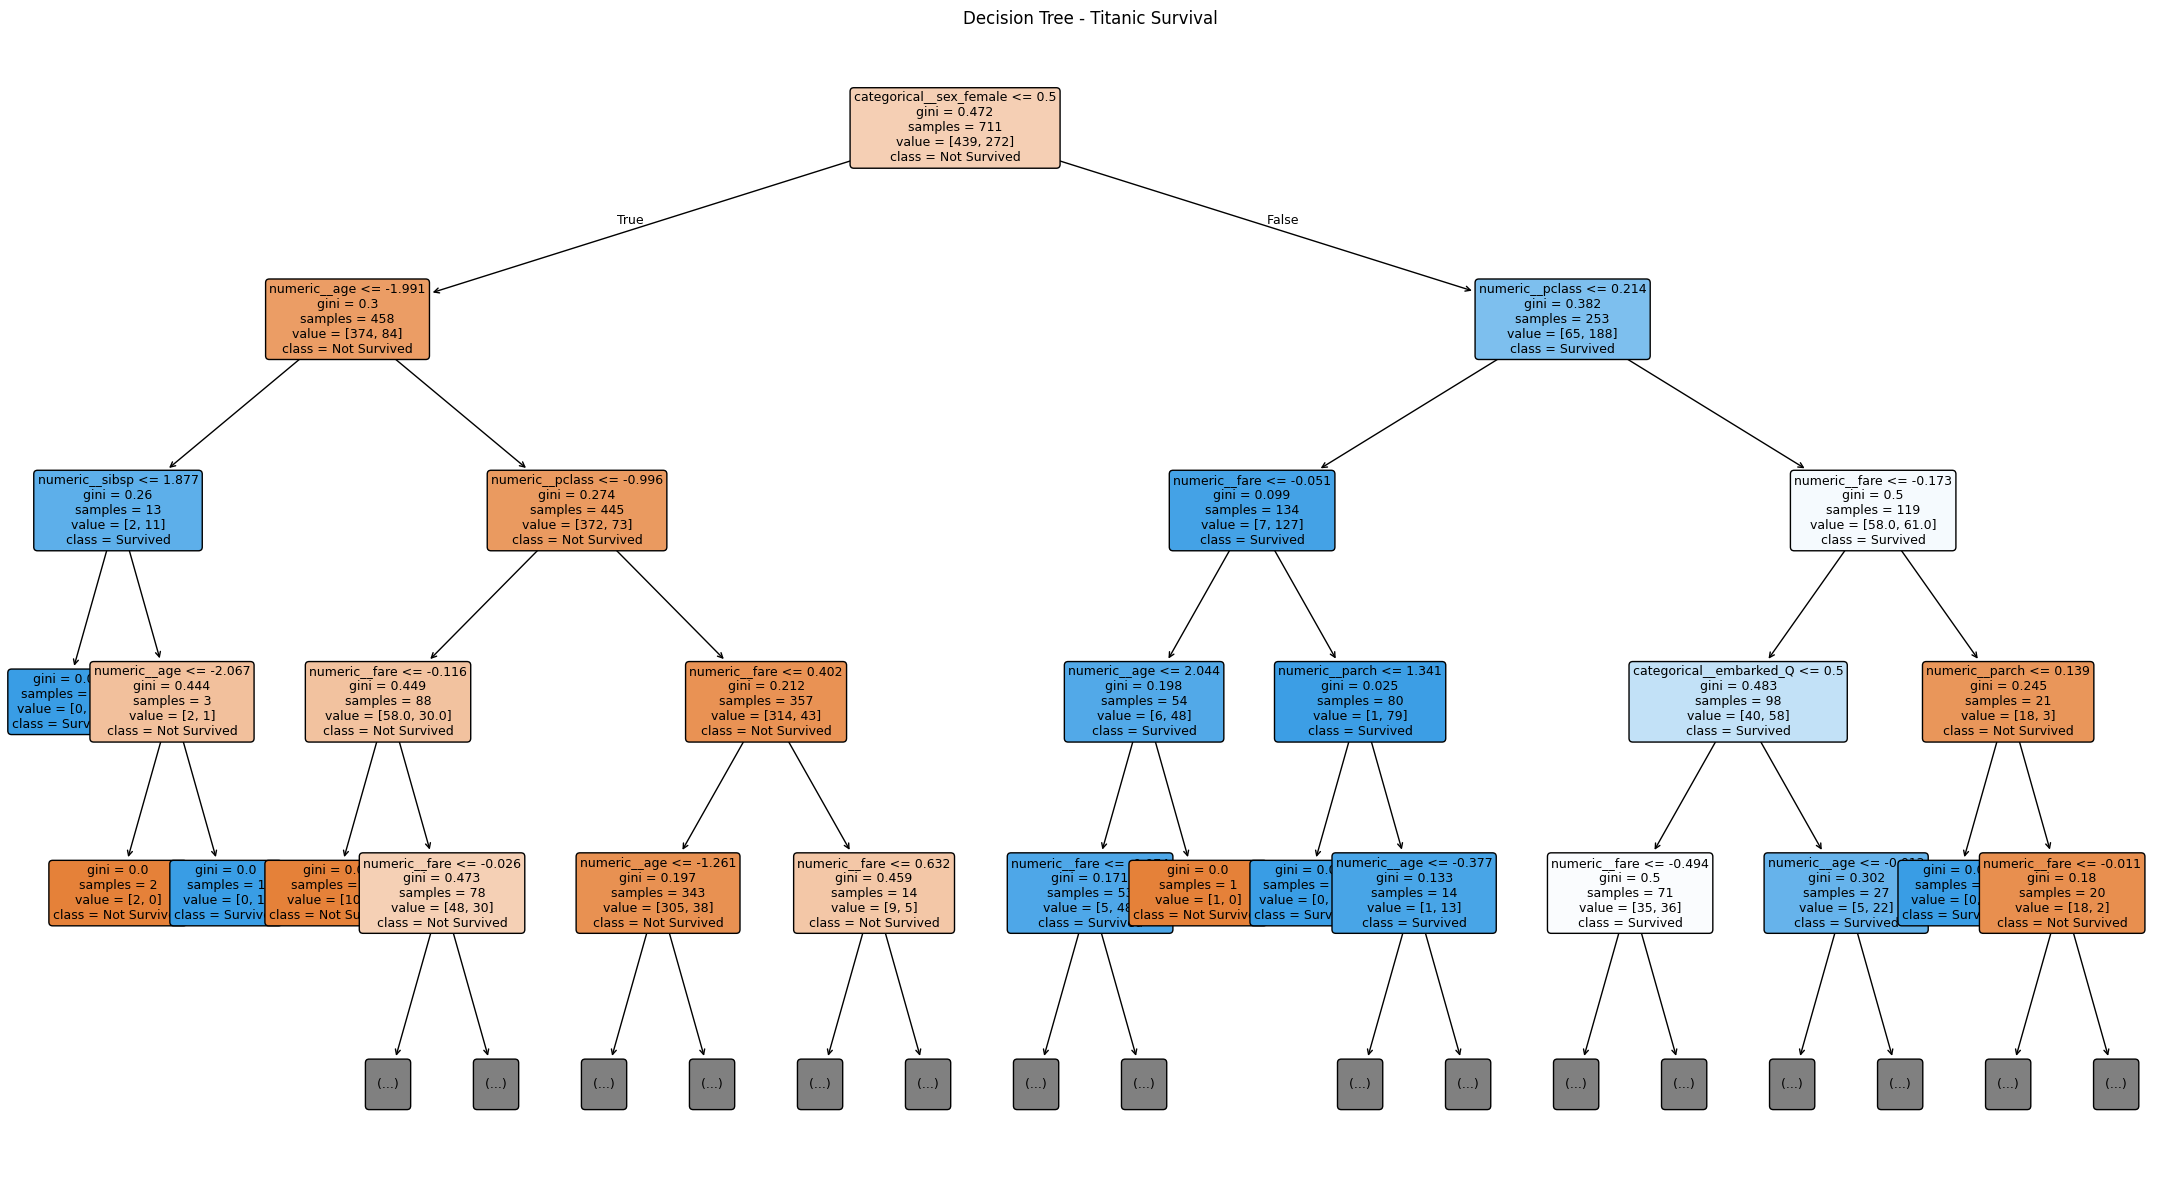

In [16]:
# ============================================================
# CELL 13 - DECISION TREE VISUALIZATION
# ============================================================

# Get the trained preprocessing and tree components
tree_preprocessor = decision_tree_model.named_steps["preprocessing"]
tree_classifier = decision_tree_model.named_steps["classifier"]

# Get feature names after encoding
tree_feature_names = (
    tree_preprocessor.get_feature_names_out()
)

plt.figure(figsize=(22, 12))

plot_tree(
    tree_classifier,
    feature_names=tree_feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title("Decision Tree - Titanic Survival")
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 14 - CLASS IMBALANCE COMPARISON
# ============================================================

# ------------------------------------------------------------
# 1. Baseline model - no imbalance handling
# ------------------------------------------------------------

baseline_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)


# ------------------------------------------------------------
# 2. Class-weight balanced model
# ------------------------------------------------------------

balanced_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

balanced_predictions = balanced_model.predict(X_test)


# ------------------------------------------------------------
# 3. SMOTE model
# ------------------------------------------------------------
# SMOTE is inside the pipeline, so it is applied only
# during training and never to the test data.

smote_model = ImbPipeline([
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

smote_model.fit(X_train, y_train)

smote_predictions = smote_model.predict(X_test)


# ------------------------------------------------------------
# Calculate comparison metrics
# ------------------------------------------------------------

imbalance_results = pd.DataFrame([
    {
        "Strategy": "Baseline",
        "Precision": precision_score(
            y_test,
            baseline_predictions
        ),
        "Recall": recall_score(
            y_test,
            baseline_predictions
        ),
        "F1": f1_score(
            y_test,
            baseline_predictions
        )
    },

    {
        "Strategy": "class_weight='balanced'",
        "Precision": precision_score(
            y_test,
            balanced_predictions
        ),
        "Recall": recall_score(
            y_test,
            balanced_predictions
        ),
        "F1": f1_score(
            y_test,
            balanced_predictions
        )
    },

    {
        "Strategy": "SMOTE",
        "Precision": precision_score(
            y_test,
            smote_predictions
        ),
        "Recall": recall_score(
            y_test,
            smote_predictions
        ),
        "F1": f1_score(
            y_test,
            smote_predictions
        )
    }
])

print("CLASS IMBALANCE COMPARISON")
display(
    imbalance_results.round(4)
)


# Identify the best strategy based on F1
best_imbalance_strategy = (
    imbalance_results.loc[
        imbalance_results["F1"].idxmax()
    ]
)

print("\nBest strategy based on F1:")
print(
    best_imbalance_strategy["Strategy"]
)

print(
    f"F1 Score: "
    f"{best_imbalance_strategy['F1']:.4f}"
)

print("""
Conclusion:
The strategy with the highest F1 score provides the best balance
between precision and recall. SMOTE is applied only to the training
data through the pipeline, preventing information from the test set
from leaking into the training process.
""")

CLASS IMBALANCE COMPARISON


,Strategy,Precision,Recall,F1
0,Baseline,0.7833,0.6912,0.7344
1,class_weight='balanced',0.7183,0.7500,0.7338
2,SMOTE,0.7353,0.7353,0.7353



Best strategy based on F1:
SMOTE
F1 Score: 0.7353

Conclusion:
The strategy with the highest F1 score provides the best balance
between precision and recall. SMOTE is applied only to the training
data through the pipeline, preventing information from the test set
from leaking into the training process.



In [18]:
# ============================================================
# CELL 15 - RANDOM FOREST GRID SEARCH + OOB SCORE
# ============================================================

# Random Forest pipeline with OOB enabled
rf_tuning_pipeline = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            random_state=42,
            oob_score=True
        )
    )
])


# Hyperparameter combinations to test
rf_parameters = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [5, 10, None],
    "classifier__max_features": ["sqrt", "log2"]
}


# GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_parameters,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


print("Running GridSearchCV...")
print("Please wait...")

rf_grid_search.fit(
    X_train,
    y_train
)


# Best model
best_random_forest = (
    rf_grid_search.best_estimator_
)


print("\nGRID SEARCH COMPLETED")
print("-" * 50)

print("\nBest Parameters:")
print(
    rf_grid_search.best_params_
)

print("\nBest Cross-Validation F1 Score:")
print(
    round(
        rf_grid_search.best_score_,
        4
    )
)


# OOB score
oob_score = (
    best_random_forest
    .named_steps["classifier"]
    .oob_score_
)

print("\nOut-of-Bag (OOB) Score:")
print(
    round(
        oob_score,
        4
    )
)

Running GridSearchCV...
Please wait...

GRID SEARCH COMPLETED
--------------------------------------------------

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7408

Out-of-Bag (OOB) Score:
0.8214


REGRESSION RESULTS
--------------------------------------------------
MAE         : 21.0986
RMSE        : 41.7021
R²          : 0.3482
Adjusted R² : 0.3091


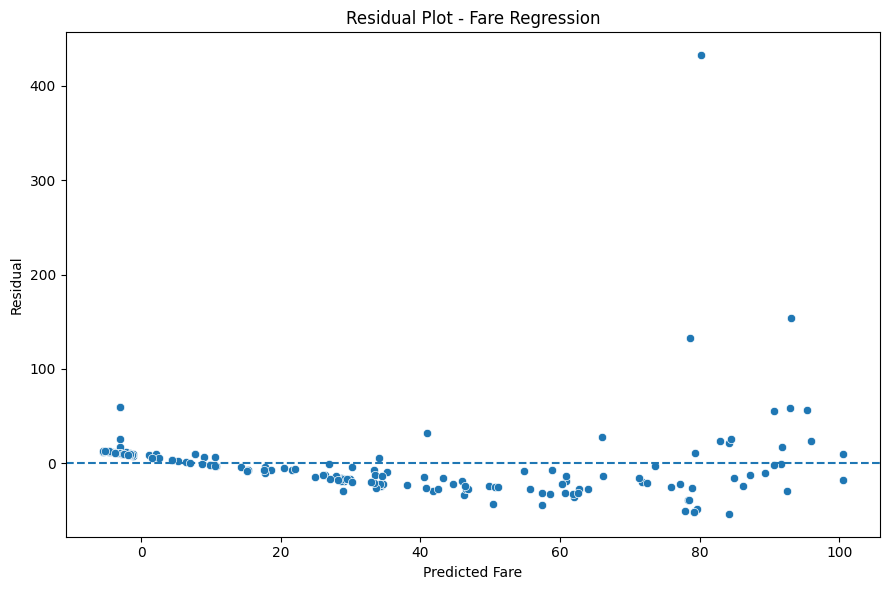


Heteroscedasticity check:
If residuals become increasingly spread out as predicted fare increases,
this indicates heteroscedasticity. If the residuals maintain a relatively
constant random spread around zero, there is no strong evidence of
heteroscedasticity.



In [19]:
# ============================================================
# CELL 16 - MULTIVARIATE LINEAR REGRESSION FOR FARE
# ============================================================

# Features used to predict fare
regression_features = [
    "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

regression_X = df[regression_features]
regression_y = df["fare"]


# Train/test split for regression
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    regression_X,
    regression_y,
    test_size=0.20,
    random_state=42
)


# Separate numerical and categorical features
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]


# Numerical preprocessing
reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing
reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combined preprocessing
regression_preprocessor = ColumnTransformer([
    (
        "numeric",
        reg_numeric_pipeline,
        reg_numeric_features
    ),
    (
        "categorical",
        reg_categorical_pipeline,
        reg_categorical_features
    )
])


# Complete regression pipeline
fare_regression_model = Pipeline([
    (
        "preprocessing",
        regression_preprocessor
    ),
    (
        "regressor",
        LinearRegression()
    )
])


# Train
fare_regression_model.fit(
    Xr_train,
    yr_train
)


# Predict
fare_predictions = fare_regression_model.predict(
    Xr_test
)


# ============================================================
# REGRESSION METRICS
# ============================================================

mae = mean_absolute_error(
    yr_test,
    fare_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        yr_test,
        fare_predictions
    )
)

r2 = r2_score(
    yr_test,
    fare_predictions
)


# Number of predictors after preprocessing
transformed_X_test = (
    fare_regression_model
    .named_steps["preprocessing"]
    .transform(Xr_test)
)

number_of_predictors = transformed_X_test.shape[1]
number_of_samples = len(yr_test)

adjusted_r2 = (
    1
    - (
        (1 - r2)
        * (number_of_samples - 1)
        / (
            number_of_samples
            - number_of_predictors
            - 1
        )
    )
)


print("REGRESSION RESULTS")
print("-" * 50)

print(f"MAE         : {mae:.4f}")
print(f"RMSE        : {rmse:.4f}")
print(f"R²          : {r2:.4f}")
print(f"Adjusted R² : {adjusted_r2:.4f}")


# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = yr_test - fare_predictions

plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=fare_predictions,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot - Fare Regression")

plt.tight_layout()
plt.show()


print("""
Heteroscedasticity check:
If residuals become increasingly spread out as predicted fare increases,
this indicates heteroscedasticity. If the residuals maintain a relatively
constant random spread around zero, there is no strong evidence of
heteroscedasticity.
""")

In [20]:
# ============================================================
# CELL 17 - FINAL MODEL COMPARISON
# ============================================================

# Display classification results
print("CLASSIFICATION MODEL COMPARISON")
print("-" * 70)

display(
    classification_results.round(4)
)


# Regression metrics as a separate group
print("\nREGRESSION MODEL METRICS")
print("-" * 70)

regression_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R2": [r2],
    "Adjusted R2": [adjusted_r2]
})

display(
    regression_results.round(4)
)


# Find best classifier based on F1
best_classifier_row = classification_results.loc[
    classification_results["F1"].idxmax()
]

print("\nFINAL RECOMMENDATION")
print("-" * 70)

print(
    f"""
Recommended classifier: {best_classifier_row["Model"]}

Accuracy : {best_classifier_row["Accuracy"]:.4f}
Precision: {best_classifier_row["Precision"]:.4f}
Recall   : {best_classifier_row["Recall"]:.4f}
F1 Score : {best_classifier_row["F1"]:.4f}
AUC      : {best_classifier_row["AUC"]:.4f}

Recommendation:
{best_classifier_row["Model"]} is recommended because it achieved
the highest F1 score among the three classification models. F1 provides
a balance between precision and recall, while AUC measures the model's
ability to distinguish between survived and not-survived passengers.
The final deployment decision is therefore based on the overall
classification performance rather than accuracy alone.
"""
)

CLASSIFICATION MODEL COMPARISON
----------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.764,0.7600,0.5588,0.6441,0.8374
2,Random Forest,0.809,0.7656,0.7206,0.7424,0.8196



REGRESSION MODEL METRICS
----------------------------------------------------------------------


,Model,MAE,RMSE,R2,Adjusted R2
0,Linear Regression,21.0986,41.7021,0.3482,0.3091



FINAL RECOMMENDATION
----------------------------------------------------------------------

Recommended classifier: Random Forest

Accuracy : 0.8090
Precision: 0.7656
Recall   : 0.7206
F1 Score : 0.7424
AUC      : 0.8196

Recommendation:
Random Forest is recommended because it achieved
the highest F1 score among the three classification models. F1 provides
a balance between precision and recall, while AUC measures the model's
ability to distinguish between survived and not-survived passengers.
The final deployment decision is therefore based on the overall
classification performance rather than accuracy alone.



In [21]:
# ============================================================
# CELL 18 - SAVE AND RELOAD COMPLETE PIPELINE
# ============================================================

import os
import shutil
import joblib

# Create analytics folder
os.makedirs("analytics", exist_ok=True)

# Select the best classifier based on F1
best_model_name = best_classifier_row["Model"]

if best_model_name == "Logistic Regression":
    full_pipeline = logistic_model

elif best_model_name == "Decision Tree":
    full_pipeline = decision_tree_model

else:
    full_pipeline = random_forest_model


# Save the complete preprocessing + model pipeline
pipeline_path = "analytics/titanic_best_pipeline.joblib"

joblib.dump(
    full_pipeline,
    pipeline_path
)

print("Complete pipeline saved successfully:")
print(pipeline_path)


# Save the cleaned Titanic dataset
csv_path = "analytics/titanic.csv"

df.to_csv(
    csv_path,
    index=False
)

print("\nCleaned dataset saved successfully:")
print(csv_path)


# ============================================================
# RELOAD THE SAVED PIPELINE
# ============================================================

loaded_pipeline = joblib.load(
    pipeline_path
)

print("\nPipeline reloaded successfully.")


# Use RAW test data - no manual preprocessing
raw_test_sample = X_test.iloc[:5]

reloaded_predictions = (
    loaded_pipeline.predict(raw_test_sample)
)

print("\nPredictions from reloaded pipeline:")
print(reloaded_predictions)


# Verify prediction count
print(
    "\nNumber of predictions:",
    len(reloaded_predictions)
)

print("""
Verification successful:
The saved pipeline can accept raw, unprocessed passenger data and
perform preprocessing and prediction end-to-end.
""")

Complete pipeline saved successfully:
analytics/titanic_best_pipeline.joblib

Cleaned dataset saved successfully:
analytics/titanic.csv

Pipeline reloaded successfully.

Predictions from reloaded pipeline:
[0 0 0 0 0]

Number of predictions: 5

Verification successful:
The saved pipeline can accept raw, unprocessed passenger data and
perform preprocessing and prediction end-to-end.



In [22]:
# ============================================================
# CELL 19 - PREPARE ANALYTICS FOLDER FOR SUBMISSION
# ============================================================

import os
import shutil

os.makedirs("analytics", exist_ok=True)

# The original raw dataset was saved immediately after loading
# as titanic.csv in Cell 2.
# Copy that exact raw CSV into the required analytics folder.
shutil.copy(
    "titanic.csv",
    "analytics/titanic.csv"
)

print("Submission folder prepared.")
print("\nFiles inside analytics:")

for filename in sorted(os.listdir("analytics")):
    print("-", filename)

Submission folder prepared.

Files inside analytics:
- titanic.csv
- titanic_best_pipeline.joblib
